# Set up

## Packages

- Testing out Getis-Ord Gi* Hotpost Analysis

I'm trying to detect cold and hot zones of pathways of interest then see what cells are in the hot spots and differences between them

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.stats import norm
from scipy.sparse.csgraph import connected_components
from sklearn.neighbors import NearestNeighbors
from statsmodels.stats.multitest import multipletests

from pathlib import Path
import spatialdata as spd
import scanpy as sc


/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## Locations

In [2]:
Gemini_proj_dir = Path("/coh_labs/yunroseli/Jona/CAR-T")

zarr_file     = Gemini_proj_dir / "data/zarr/fullDataset/processing_Zarr/1_C2l_annotated_CC"
pathway_dir   = Gemini_proj_dir / "data/references/pathways"


gmt_files = {
    "hallmark": pathway_dir / "mh.all.v2026.1.Mm.symbols.gmt",
    "reactome": pathway_dir / "m2.cp.reactome.v2026.1.Mm.symbols.gmt",
    "go_bp":    pathway_dir / "m5.go.bp.v2026.1.Mm.symbols.gmt",
    "curated":  pathway_dir / "m2.cp.v2026.1.Mm.symbols.gmt",
}




## Loading Data


In [3]:

sdata = spd.read_zarr(zarr_file)
adata = sdata.tables['segmentation_counts']

In [4]:
# Reading and parsing GMT files
def read_gmt(gmt_path):
    gene_sets = {}
    rows = []
    with open(gmt_path, "r") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            gene_set    = parts[0]
            description = parts[1]
            genes       = parts[2:]
            gene_sets[gene_set] = genes
            rows.append({
                "gene_set":    gene_set,
                "description": description,
                "n_genes":     len(genes),
                "source_file": Path(gmt_path).name,
            })
    return gene_sets, pd.DataFrame(rows)

all_gene_sets = {}
gene_set_metadata_list = []

for collection, path in gmt_files.items():
    gs, meta = read_gmt(path)
    meta["collection"] = collection
    all_gene_sets.update(gs)
    gene_set_metadata_list.append(meta)

gene_set_metadata = pd.concat(gene_set_metadata_list, ignore_index=True)
print(f"Total gene sets loaded: {len(all_gene_sets):,}")
display(gene_set_metadata.groupby("collection")[["gene_set"]].count())




Total gene sets loaded: 9,618


,gene_set
collection,
curated,1787
go_bp,7781
hallmark,50
reactome,1333


## Pathway Scoring

## PathwayLists

In [5]:
pathway_panel = {
    # IFN/inflammatory activation
    "IFN_gamma": "HALLMARK_INTERFERON_GAMMA_RESPONSE",

    # Broad antigen processing/presentation
    "AntigenPresentation_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION"
    ),

    # Peptide antigen presentation
    "PeptideAntigenPresentation_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PEPTIDE_ANTIGEN"
    ),

    # Exogenous antigen presentation
    "ExogenousAntigenPresentation_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGENOUS_ANTIGEN"
    ),

    # Exogenous peptide antigen presentation
    "ExogenousPeptideAntigenPresentation_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGENOUS_PEPTIDE_ANTIGEN"
    ),

    # MHC-II/exogenous peptide antigen presentation
    "MHCII_ExogenousPeptide_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGENOUS_PEPTIDE_ANTIGEN_VIA_MHC_CLASS_II"
    ),

    # MHC-II peptide/polysaccharide antigen presentation
    "MHCII_PeptidePolysaccharide_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PEPTIDE_OR_POLYSACCHARIDE_ANTIGEN_VIA_MHC_CLASS_II"
    ),

    # MHC-I antigen presentation
    "MHCI_PeptideAntigen_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PEPTIDE_ANTIGEN_VIA_MHC_CLASS_I"
    ),

    # Cytokine/inflammatory macrophage activation
    "IL6Production_GO": (
        "GOBP_INTERLEUKIN_6_PRODUCTION"
    ),

    "TNFSFCytokineProduction_GO": (
        "GOBP_TUMOR_NECROSIS_FACTOR_SUPERFAMILY_CYTOKINE_PRODUCTION"
    ),
}

In [6]:
debris_antigen_presentation_panel = {
    # ---------------------------------------------------------------------
    # 1. Killing / cell death generation
    # ---------------------------------------------------------------------
    "GranzymeDeath_GO": (
        "GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY"
    ),
    "ApoptoticSignaling_GO": (
        "GOBP_APOPTOTIC_SIGNALING_PATHWAY"
    ),
    "ProgrammedCellDeath_GO": (
        "GOBP_PROGRAMMED_CELL_DEATH"
    ),
    "PositiveRegApoptosis_GO": (
        "GOBP_POSITIVE_REGULATION_OF_APOPTOTIC_PROCESS"
    ),
    "DNADamageResponse_GO": (
        "GOBP_DNA_DAMAGE_RESPONSE"
    ),
    "P53MediatedDNADamage_GO": (
        "GOBP_INTRINSIC_APOPTOTIC_SIGNALING_PATHWAY_BY_P53_CLASS_MEDIATOR"
    ),

    # ---------------------------------------------------------------------
    # 2. Debris recognition / phagocytosis / efferocytosis
    # ---------------------------------------------------------------------
    "Phagocytosis_GO": (
        "GOBP_PHAGOCYTOSIS"
    ),
    "RegulationOfPhagocytosis_GO": (
        "GOBP_REGULATION_OF_PHAGOCYTOSIS"
    ),
    "PositiveRegulationOfPhagocytosis_GO": (
        "GOBP_POSITIVE_REGULATION_OF_PHAGOCYTOSIS"
    ),
    "PhagocytosisEngulfment_GO": (
        "GOBP_PHAGOCYTOSIS_ENGULFMENT"
    ),
    "EngulfmentOfApoptoticCell_GO": (
        "GOBP_ENGULFMENT_OF_APOPTOTIC_CELL"
    ),

    # ---------------------------------------------------------------------
    # 3. Uptake routes: endocytosis / macropinocytosis
    # ---------------------------------------------------------------------
    "Endocytosis_GO": (
        "GOBP_ENDOCYTOSIS"
    ),
    "ReceptorMediatedEndocytosis_GO": (
        "GOBP_RECEPTOR_MEDIATED_ENDOCYTOSIS"
    ),
    "Macropinocytosis_GO": (
        "GOBP_MACROPINOCYTOSIS"
    ),

    # ---------------------------------------------------------------------
    # 4. Endosome / lysosome / proteolytic processing
    # ---------------------------------------------------------------------
    "LysosomeOrganization_GO": (
        "GOBP_LYSOSOME_ORGANIZATION"
    ),
    "VacuolarAcidification_GO": (
        "GOBP_VACUOLAR_ACIDIFICATION"
    ),
    "EndosomeToLysosomeTransport_GO": (
        "GOBP_ENDOSOME_TO_LYSOSOME_TRANSPORT"
    ),
    "Proteolysis_GO": (
        "GOBP_PROTEOLYSIS"
    ),

    # ---------------------------------------------------------------------
    # 5. Broad antigen processing and presentation
    # ---------------------------------------------------------------------
    "AntigenPresentation_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION"
    ),
    "PeptideAntigenPresentation_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PEPTIDE_ANTIGEN"
    ),
    "ExogenousAntigenPresentation_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGENOUS_ANTIGEN"
    ),
    "ExogenousPeptideAntigenPresentation_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGENOUS_PEPTIDE_ANTIGEN"
    ),

    # ---------------------------------------------------------------------
    # 6. MHC-II presentation: most relevant to debris/exogenous antigen
    # ---------------------------------------------------------------------
    "MHCII_ExogenousPeptide_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGENOUS_PEPTIDE_ANTIGEN_VIA_MHC_CLASS_II"
    ),
    "MHCII_PeptidePolysaccharide_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PEPTIDE_OR_POLYSACCHARIDE_ANTIGEN_VIA_MHC_CLASS_II"
    ),
    "MHCII_Reactome": (
        "REACTOME_MHC_CLASS_II_ANTIGEN_PRESENTATION"
    ),

    # ---------------------------------------------------------------------
    # 7. MHC-I / cross-presentation: extracellular antigen routed to MHC-I
    # ---------------------------------------------------------------------
    "MHCI_PeptideAntigen_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PEPTIDE_ANTIGEN_VIA_MHC_CLASS_I"
    ),
    "CrossPresentation_Reactome": (
        "REACTOME_ANTIGEN_PROCESSING_CROSS_PRESENTATION"
    ),
    "MHCI_Reactome": (
        "REACTOME_CLASS_I_MHC_MEDIATED_ANTIGEN_PROCESSING_PRESENTATION"
    ),

    # ---------------------------------------------------------------------
    # 8. T-cell activation context
    # ---------------------------------------------------------------------
    "TCellActivation_GO": (
        "GOBP_T_CELL_ACTIVATION"
    ),
    "PositiveRegulationTCellActivation_GO": (
        "GOBP_POSITIVE_REGULATION_OF_T_CELL_ACTIVATION"
    ),
    "RegulationOfTCellActivation_GO": (
        "GOBP_REGULATION_OF_T_CELL_ACTIVATION"
    ),

    # ---------------------------------------------------------------------
    # 9. IFN / inflammatory context
    # ---------------------------------------------------------------------
    "IFN_gamma": (
        "HALLMARK_INTERFERON_GAMMA_RESPONSE"
    ),
    "IFNg_Reactome": (
        "REACTOME_INTERFERON_GAMMA_SIGNALING"
    ),
    "IL6Production_GO": (
        "GOBP_INTERLEUKIN_6_PRODUCTION"
    ),
    "TNFSFCytokineProduction_GO": (
        "GOBP_TUMOR_NECROSIS_FACTOR_SUPERFAMILY_CYTOKINE_PRODUCTION"
    ),
}

In [7]:
neutrophil_context_panel = {
    # Neutrophil identity / activation
    "NeutrophilMediatedImmunity_GO": (
        "GOBP_NEUTROPHIL_MEDIATED_IMMUNITY"
    ),
    "NeutrophilActivation_GO": (
        "GOBP_NEUTROPHIL_ACTIVATION"
    ),
    "NeutrophilActivationImmuneResponse_GO": (
        "GOBP_NEUTROPHIL_ACTIVATION_INVOLVED_IN_IMMUNE_RESPONSE"
    ),
    "NeutrophilDegranulation_GO": (
        "GOBP_NEUTROPHIL_DEGRANULATION"
    ),

    # Movement into inflammatory/debris-rich tissue
    "NeutrophilMigration_GO": (
        "GOBP_NEUTROPHIL_MIGRATION"
    ),
    "GranulocyteChemotaxis_GO": (
        "GOBP_GRANULOCYTE_CHEMOTAXIS"
    ),
    "GranulocyteMigration_GO": (
        "GOBP_GRANULOCYTE_MIGRATION"
    ),

    # Killing / oxidative processing
    "RespiratoryBurst_GO": (
        "GOBP_RESPIRATORY_BURST"
    ),
    "ROSProduction_GO": (
        "GOBP_REACTIVE_OXYGEN_SPECIES_METABOLIC_PROCESS"
    ),

    # Debris/pathogen uptake and processing
    "Phagocytosis_GO": (
        "GOBP_PHAGOCYTOSIS"
    ),
    "PhagocytosisEngulfment_GO": (
        "GOBP_PHAGOCYTOSIS_ENGULFMENT"
    ),
    "LysosomeOrganization_GO": (
        "GOBP_LYSOSOME_ORGANIZATION"
    ),

    # Antigen presentation checks
    "AntigenPresentation_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION"
    ),
    "MHCII_ExogenousPeptide_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGENOUS_PEPTIDE_ANTIGEN_VIA_MHC_CLASS_II"
    ),
    "MHCII_Reactome": (
        "REACTOME_MHC_CLASS_II_ANTIGEN_PRESENTATION"
    ),
}

In [8]:
debris_to_presentation_primary_panel = {
    "GranzymeDeath_GO": (
        "GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY"
    ),
    "Phagocytosis_GO": (
        "GOBP_PHAGOCYTOSIS"
    ),
    "EngulfmentOfApoptoticCell_GO": (
        "GOBP_ENGULFMENT_OF_APOPTOTIC_CELL"
    ),
    "LysosomeOrganization_GO": (
        "GOBP_LYSOSOME_ORGANIZATION"
    ),
    "AntigenPresentation_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION"
    ),
    "MHCII_ExogenousPeptide_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGENOUS_PEPTIDE_ANTIGEN_VIA_MHC_CLASS_II"
    ),
    "CrossPresentation_Reactome": (
        "REACTOME_ANTIGEN_PROCESSING_CROSS_PRESENTATION"
    ),
    "IFN_gamma": (
        "HALLMARK_INTERFERON_GAMMA_RESPONSE"
    ),
}

## Scoring

In [9]:
PathwayGroupsSelection = debris_to_presentation_primary_panel

In [10]:
# --- Validation: confirms every entry exists in all_gene_sets ---
panel_check = []
for short_name, gene_set_name in PathwayGroupsSelection.items(): #pathway_panel.items():
    found = gene_set_name in all_gene_sets
    panel_check.append({
        "short_name":    short_name,
        "gene_set_name": gene_set_name,
        "found":         found,
        "n_genes":       len(all_gene_sets[gene_set_name]) if found else np.nan,
        "collection":    gene_set_metadata.loc[
                             gene_set_metadata["gene_set"].eq(gene_set_name), "collection"
                         ].iloc[0] if found else "NOT FOUND",
    })

display(pd.DataFrame(panel_check))

,short_name,gene_set_name,found,n_genes,collection
0,GranzymeDeath_GO,GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_S...,True,11.0,go_bp
1,Phagocytosis_GO,GOBP_PHAGOCYTOSIS,True,248.0,go_bp
2,EngulfmentOfApoptoticCell_GO,GOBP_ENGULFMENT_OF_APOPTOTIC_CELL,True,12.0,go_bp
3,LysosomeOrganization_GO,GOBP_LYSOSOME_ORGANIZATION,False,NaN,NOT FOUND
4,AntigenPresentation_GO,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION,True,133.0,go_bp
5,MHCII_ExogenousPeptide_GO,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EX...,True,20.0,go_bp
6,CrossPresentation_Reactome,REACTOME_ANTIGEN_PROCESSING_CROSS_PRESENTATION,True,68.0,reactome
7,IFN_gamma,HALLMARK_INTERFERON_GAMMA_RESPONSE,True,188.0,hallmark


In [11]:
# --- Score each pathway in the panel ---
#

available_genes = set(adata.var_names.astype(str))
score_records   = []

for short_name, gene_set_name in PathwayGroupsSelection.items():
    pathway_genes = all_gene_sets.get(gene_set_name, [])
    matched       = [g for g in pathway_genes if g in available_genes]
    score_col     = f"{short_name}_score"

    print(f"Scoring {short_name!r}  ({len(matched)}/{len(pathway_genes)} genes matched)...")

    if len(matched) < 5:
        print(f"  WARNING: too few matched genes — skipping.")
        continue

    sc.tl.score_genes(adata, gene_list=matched, score_name=score_col, use_raw=False)
    score_records.append({"short_name": short_name, "score_col": score_col, "n_matched": len(matched)})

print("\nDone. Score columns added to adata.obs:")
display(pd.DataFrame(score_records))
# Use these column names in the visualization cells below:
#   pathway_score = "IFN_gamma_score"
#   pathway_score = "Glycolysis_score"

Scoring 'GranzymeDeath_GO'  (10/11 genes matched)...
Scoring 'Phagocytosis_GO'  (241/248 genes matched)...
Scoring 'EngulfmentOfApoptoticCell_GO'  (12/12 genes matched)...
Scoring 'LysosomeOrganization_GO'  (0/0 genes matched)...
Scoring 'AntigenPresentation_GO'  (117/133 genes matched)...
Scoring 'MHCII_ExogenousPeptide_GO'  (19/20 genes matched)...
Scoring 'CrossPresentation_Reactome'  (65/68 genes matched)...
Scoring 'IFN_gamma'  (180/188 genes matched)...

Done. Score columns added to adata.obs:


,short_name,score_col,n_matched
0,GranzymeDeath_GO,GranzymeDeath_GO_score,10
1,Phagocytosis_GO,Phagocytosis_GO_score,241
2,EngulfmentOfApoptoticCell_GO,EngulfmentOfApoptoticCell_GO_score,12
3,AntigenPresentation_GO,AntigenPresentation_GO_score,117
4,MHCII_ExogenousPeptide_GO,MHCII_ExogenousPeptide_GO_score,19
5,CrossPresentation_Reactome,CrossPresentation_Reactome_score,65
6,IFN_gamma,IFN_gamma_score,180


# Variables

In [39]:
adata.obs['c2l_permissive'].unique().tolist()

['Classical_Mono',
 'Unknown',
 'N1_like_Neu',
 'Nonclassical_Mono',
 'M1_like_Mac',
 'CD8_T',
 'M2_like_Mac',
 'Erythrocyte',
 'Fibroblast',
 'NK',
 'Cancer_cell',
 'cDC',
 'Endothelial',
 'N2_like_Neu',
 'pDC',
 'CD4_T',
 'B',
 'Treg',
 'NKT',
 'Intermediate_Mac']

In [34]:
# -----------------------------
# Core columns in your object
# -----------------------------
tissue_col = "tissue"
cell_type_col = "c2l_permissive"
condition_col = "treatment"  # change if needed

# -----------------------------
# Pathway scores to hotspot
# -----------------------------

score_cols = [
    # Killing / cytotoxic effector activity
    "GranzymeDeath_GO_score",
    "TcellCytotoxicity_GO_score",

    # Cleaning / dead-cell or debris uptake
    "EngulfmentOfApoptoticCell_GO_score",
    "PhagocytosisEngulfment_GO_score",

    # Intracellular processing of engulfed material
    "VacuolarAcidification_GO_score",
    "EndosomeToLysosomeTransport_GO_score",

    # Antigen presentation
    "AntigenPresentation_GO_score",
    "MHCII_ExogenousPeptide_GO_score",
    "CrossPresentation_Reactome_score",

    # Inflammatory/APC activation context
    "IFN_gamma_score",
]

score_cols = [c for c in score_cols if c in adata.obs.columns]
print("Scores found:")
print(score_cols)

# -----------------------------
# Cell types to calculate distance to
# -----------------------------
target_cell_types = [
    "NK",
    "CD8_T",
    "M1_like_Mac",
    "M2_like_Mac",
    "cDC",
    "N1_like_Neu",
    "N2_like_Neu",
    "Cancer_cell",
]

target_cell_types = [
    ct for ct in target_cell_types
    if ct in set(adata.obs[cell_type_col].astype(str))
]
print("\nTarget cell types found:")
print(target_cell_types)

# -----------------------------
# Tissues to run
# Use None to run all tissues
# -----------------------------
tissues_to_run = None
tissues_to_run = ['RTCyPSCA_1_4', 'RTCyPSCA_2_4', 'RTCyPSCA_1_3', 'RTCyPSCA_2_3', 'RTCyPSCA_1_2', 'RTCyPSCA_1_5']
MICRONS_PER_PIXEL = 0.34

# -----------------------------
# Getis-Ord parameters
# -----------------------------
k_gi = 50          # neighborhood size for segmented cells
alpha = 0.05      # FDR cutoff
min_cells = 100   # skip tiny tissues

print("\nSettings:")
print(f"k_gi={k_gi}, alpha={alpha}, min_cells={min_cells}")

Scores found:
['GranzymeDeath_GO_score', 'EngulfmentOfApoptoticCell_GO_score', 'AntigenPresentation_GO_score', 'MHCII_ExogenousPeptide_GO_score', 'CrossPresentation_Reactome_score', 'IFN_gamma_score']

Target cell types found:
['NK', 'CD8_T', 'M1_like_Mac', 'M2_like_Mac', 'cDC', 'N1_like_Neu', 'N2_like_Neu', 'Cancer_cell']

Settings:
k_gi=50, alpha=0.05, min_cells=100


In [13]:
# %%
from spatialdata.transformations import get_transformation

# Distances are reported in microns.
distance_thresholds_um = [25, 50, 100]

# If your adata.obsm["spatial"] coordinates need the same scale used for H&E overlay,
# keep this True. This matches your older plotting logic: raw_coords * scale.
APPLY_HIRES_SCALE = True

# Used only for labeling separate hotspot islands/components.
hotspot_component_radius_um = 50
min_hotspot_component_cells = 10

# Functions

In [14]:
def get_tissue_scale_to_hires(sdata, tissue_name):
    """
    Returns the scale used to map cell coordinates to the hires H&E image.
    Translation is ignored because translation does not affect distances.
    """
    shapes_key = f"{tissue_name}_cell_boundaries"
    cs = "downscale_to_hires"

    if shapes_key not in sdata.shapes:
        print(f"WARNING: {shapes_key} not found in sdata.shapes. Using scale=1.")
        return 1.0

    try:
        shapes_tf = get_transformation(sdata.shapes[shapes_key], get_all=True)[cs]
        return float(shapes_tf.scale[0])
    except Exception as e:
        print(f"WARNING: Could not get hires scale for {tissue_name}. Using scale=1. Error: {e}")
        return 1.0


def get_tissue_coords_um(adata, sdata, tissue_name):
    """
    Returns:
        tissue_mask: boolean mask for cells in this tissue
        coords_um: x/y coordinates in microns
        scale_to_hires: scale applied before micron conversion

    Coordinate conversion:
        adata.obsm["spatial"] -> H&E pixels -> microns

    Final:
        coords_um = adata.obsm["spatial"] * scale_to_hires * MICRONS_PER_PIXEL
    """
    tissue_mask = adata.obs[tissue_col].astype(str).eq(str(tissue_name)).values
    coords = np.asarray(adata.obsm["spatial"][tissue_mask], dtype=float)

    scale_to_hires = 1.0
    if APPLY_HIRES_SCALE:
        scale_to_hires = get_tissue_scale_to_hires(sdata, tissue_name)
        coords = coords * scale_to_hires

    coords_um = coords * MICRONS_PER_PIXEL
    return tissue_mask, coords_um, scale_to_hires


def calc_getis_ord_gi_star(coords_um, values, k=50):
    """
    Fast Getis-Ord Gi* using binary k-nearest-neighbor weights.
    Includes self in the neighborhood, so this is Gi* rather than Gi.

    Positive z-score = local high-value clustering.
    Negative z-score = local low-value clustering.
    """
    values = np.asarray(values, dtype=float)
    n = len(values)

    if n < k + 2:
        raise ValueError(f"Not enough cells for k={k}: n={n}")

    if np.nanstd(values) == 0:
        z = np.full(n, np.nan)
        q_hot = np.full(n, np.nan)
        q_cold = np.full(n, np.nan)
        return z, q_hot, q_cold

    # k + 1 because self is included
    n_neighbors = min(k + 1, n)

    nn = NearestNeighbors(n_neighbors=n_neighbors, algorithm="auto")
    nn.fit(coords_um)
    _, idx = nn.kneighbors(coords_um)

    local_sum = values[idx].sum(axis=1)

    xbar = values.mean()
    s = values.std(ddof=0)

    sum_w = idx.shape[1]
    sum_w2 = sum_w

    denom = s * np.sqrt((n * sum_w2 - sum_w**2) / (n - 1))
    z = (local_sum - xbar * sum_w) / denom

    p_hot = norm.sf(z)
    p_cold = norm.cdf(z)

    q_hot = multipletests(p_hot, method="fdr_bh")[1]
    q_cold = multipletests(p_cold, method="fdr_bh")[1]

    return z, q_hot, q_cold


def label_hotspot_components(coords_um, hotspot_mask, radius_um=50, min_cells=10):
    """
    Labels separate hotspot islands using a radius-neighbor graph.
    Returns -1 for non-hotspot cells or tiny hotspot components.
    """
    labels_full = np.full(len(hotspot_mask), -1, dtype=int)

    if hotspot_mask.sum() < min_cells:
        return labels_full

    hot_coords = coords_um[hotspot_mask]

    nn = NearestNeighbors(radius=radius_um)
    nn.fit(hot_coords)
    graph = nn.radius_neighbors_graph(hot_coords, mode="connectivity")

    n_components, component_labels = connected_components(
        graph,
        directed=False,
        return_labels=True
    )

    component_sizes = pd.Series(component_labels).value_counts().to_dict()

    kept_component_labels = np.array([
        lab if component_sizes.get(lab, 0) >= min_cells else -1
        for lab in component_labels
    ])

    labels_full[hotspot_mask] = kept_component_labels
    return labels_full


def quick_hotspot_plot(adata, sdata, tissue_name, score_col, overlay_cell_types=("NK", "M1_like_Mac", "Cancer_cell")):
    """
    Quick scatter plot in micron coordinates.
    """
    tissue_mask, coords_um, scale_to_hires = get_tissue_coords_um(adata, sdata, tissue_name)
    obs = adata.obs.loc[tissue_mask].copy()

    hot_col = f"{score_col}_hotspot"
    if hot_col not in obs.columns:
        raise ValueError(f"{hot_col} not found. Run the Gi* cell first.")

    hot = obs[hot_col].astype(bool).values

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.scatter(
        coords_um[:, 0],
        coords_um[:, 1],
        s=1,
        c="lightgray",
        alpha=0.35,
        linewidths=0,
        rasterized=True,
        label="All cells"
    )

    ax.scatter(
        coords_um[hot, 0],
        coords_um[hot, 1],
        s=4,
        c="red",
        alpha=0.85,
        linewidths=0,
        rasterized=True,
        label=f"{score_col} hotspot"
    )

    for ct in overlay_cell_types:
        ct_mask = obs[cell_type_col].astype(str).eq(ct).values
        if ct_mask.sum() == 0:
            continue

        ax.scatter(
            coords_um[ct_mask, 0],
            coords_um[ct_mask, 1],
            s=10,
            alpha=0.9,
            linewidths=0,
            rasterized=True,
            label=ct
        )

    ax.set_title(
        f"{tissue_name}\n{score_col} hotspots\n"
        f"scale_to_hires={scale_to_hires:.4f}, 1 pixel={MICRONS_PER_PIXEL} µm",
        fontsize=10
    )
    ax.set_xlabel("x position (µm)")
    ax.set_ylabel("y position (µm)")
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.legend(markerscale=3, fontsize=8, frameon=True)
    plt.tight_layout()
    display(fig)
    plt.close(fig)

# Analysis

In [54]:
# %% [markdown]
# # Coordinate sanity check

# %%
if tissues_to_run is None:
    tissues_to_run = sorted(adata.obs[tissue_col].astype(str).unique())

test_tissue = tissues_to_run[0]

test_mask, test_coords_um, test_scale = get_tissue_coords_um(adata, sdata, test_tissue)

print(f"Micron conversion: 1 H&E pixel = {MICRONS_PER_PIXEL} µm")
print(f"Test tissue: {test_tissue}")
print(f"Cells in test tissue: {test_mask.sum():,}")
print(f"Scale to hires image: {test_scale:.6f}")
print(f"x range: {test_coords_um[:, 0].min():.1f} to {test_coords_um[:, 0].max():.1f} µm")
print(f"y range: {test_coords_um[:, 1].min():.1f} to {test_coords_um[:, 1].max():.1f} µm")
print(f"Approx tissue width:  {np.ptp(test_coords_um[:, 0]):.1f} µm")
print(f"Approx tissue height: {np.ptp(test_coords_um[:, 1]):.1f} µm")

Micron conversion: 1 H&E pixel = 0.34 µm
Test tissue: RTCyPSCA_1_2
Cells in test tissue: 28,637
Scale to hires image: 0.234119
x range: 914.8 to 1658.6 µm
y range: 1051.1 to 1656.2 µm
Approx tissue width:  743.8 µm
Approx tissue height: 605.1 µm


In [55]:
# # Run Getis-Ord Gi* hotspots for pathway scores

# %%
# Initialize columns
for score_col in score_cols:
    adata.obs[f"{score_col}_GiZ"] = np.nan
    adata.obs[f"{score_col}_q_hot"] = np.nan
    adata.obs[f"{score_col}_q_cold"] = np.nan
    adata.obs[f"{score_col}_hotspot"] = False
    adata.obs[f"{score_col}_coldspot"] = False
    adata.obs[f"{score_col}_hotspot_component"] = -1

hotspot_summary = []

for tissue_name in tissues_to_run:
    tissue_mask, coords_um, scale_to_hires = get_tissue_coords_um(adata, sdata, tissue_name)
    obs_names = adata.obs_names[tissue_mask]
    n_cells = tissue_mask.sum()

    if n_cells < min_cells:
        print(f"Skipping {tissue_name}: only {n_cells:,} cells")
        continue

    treatment = (
        adata.obs.loc[tissue_mask, condition_col].astype(str).iloc[0]
        if condition_col in adata.obs.columns
        else "NA"
    )

    print(f"\nRunning tissue: {tissue_name} | treatment={treatment} | n={n_cells:,}")

    for score_col in score_cols:
        values = adata.obs.loc[tissue_mask, score_col].astype(float).values
        good = np.isfinite(values)

        if good.sum() < min_cells:
            print(f"  Skipping {score_col}: only {good.sum():,} finite values")
            continue

        z, q_hot, q_cold = calc_getis_ord_gi_star(
            coords_um=coords_um[good],
            values=values[good],
            k=k_gi
        )

        hotspot = (z > 0) & (q_hot < alpha)
        coldspot = (z < 0) & (q_cold < alpha)

        component_labels = label_hotspot_components(
            coords_um=coords_um[good],
            hotspot_mask=hotspot,
            radius_um=hotspot_component_radius_um,
            min_cells=min_hotspot_component_cells
        )

        sub_obs_names = obs_names[good]

        adata.obs.loc[sub_obs_names, f"{score_col}_GiZ"] = z
        adata.obs.loc[sub_obs_names, f"{score_col}_q_hot"] = q_hot
        adata.obs.loc[sub_obs_names, f"{score_col}_q_cold"] = q_cold
        adata.obs.loc[sub_obs_names, f"{score_col}_hotspot"] = hotspot
        adata.obs.loc[sub_obs_names, f"{score_col}_coldspot"] = coldspot
        adata.obs.loc[sub_obs_names, f"{score_col}_hotspot_component"] = component_labels

        n_components = len(set(component_labels[component_labels >= 0]))

        hotspot_summary.append({
            "tissue": tissue_name,
            "treatment": treatment,
            "score_col": score_col,
            "n_cells": int(n_cells),
            "k_gi": int(k_gi),
            "alpha": float(alpha),
            "microns_per_pixel": float(MICRONS_PER_PIXEL),
            "scale_to_hires": float(scale_to_hires),
            "n_hotspot_cells": int(hotspot.sum()),
            "pct_hotspot_cells": float(hotspot.mean() * 100),
            "n_coldspot_cells": int(coldspot.sum()),
            "pct_coldspot_cells": float(coldspot.mean() * 100),
            "n_hotspot_components": int(n_components),
            "median_GiZ_hotspot": float(np.nanmedian(z[hotspot])) if hotspot.sum() else np.nan,
        })

        print(
            f"  {score_col}: "
            f"hot={hotspot.sum():,} ({hotspot.mean()*100:.1f}%), "
            f"cold={coldspot.sum():,} ({coldspot.mean()*100:.1f}%), "
            f"components={n_components}"
        )

hotspot_summary_df = pd.DataFrame(hotspot_summary)

display(
    hotspot_summary_df
    .sort_values(["score_col", "tissue"])
    .reset_index(drop=True)
)


Running tissue: RTCyPSCA_1_2 | treatment=RTCyPSCA_Tu1 | n=28,637
  GranzymeDeath_GO_score: hot=7,965 (27.8%), cold=7,665 (26.8%), components=1
  EngulfmentOfApoptoticCell_GO_score: hot=5,829 (20.4%), cold=7,015 (24.5%), components=3
  PhagocytosisEngulfment_GO_score: hot=6,491 (22.7%), cold=5,982 (20.9%), components=4
  VacuolarAcidification_GO_score: hot=6,809 (23.8%), cold=6,737 (23.5%), components=2
  EndosomeToLysosomeTransport_GO_score: hot=280 (1.0%), cold=194 (0.7%), components=8
  AntigenPresentation_GO_score: hot=12,001 (41.9%), cold=9,942 (34.7%), components=1
  MHCII_ExogenousPeptide_GO_score: hot=11,333 (39.6%), cold=9,752 (34.1%), components=2
  CrossPresentation_Reactome_score: hot=10,654 (37.2%), cold=7,662 (26.8%), components=1
  IFN_gamma_score: hot=12,305 (43.0%), cold=11,080 (38.7%), components=2

Running tissue: RTCyPSCA_2_3 | treatment=RTCyPSCA_Tu2 | n=112,486
  GranzymeDeath_GO_score: hot=28,788 (25.6%), cold=40,458 (36.0%), components=10
  EngulfmentOfApoptoticC

,tissue,treatment,score_col,n_cells,k_gi,alpha,microns_per_pixel,scale_to_hires,n_hotspot_cells,pct_hotspot_cells,n_coldspot_cells,pct_coldspot_cells,n_hotspot_components,median_GiZ_hotspot
0,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,28637,50,0.05,0.34,0.234119,12001,41.907323,9942,34.717324,1,4.743088
1,RTCyPSCA_2_3,RTCyPSCA_Tu2,AntigenPresentation_GO_score,112486,50,0.05,0.34,0.230574,29571,26.288605,47073,41.847874,17,7.227810
2,RTCyPSCA_1_2,RTCyPSCA_Tu1,CrossPresentation_Reactome_score,28637,50,0.05,0.34,0.234119,10654,37.203618,7662,26.755596,1,3.348070
3,RTCyPSCA_2_3,RTCyPSCA_Tu2,CrossPresentation_Reactome_score,112486,50,0.05,0.34,0.230574,11529,10.249275,14076,12.513557,4,3.232948
4,RTCyPSCA_1_2,RTCyPSCA_Tu1,EndosomeToLysosomeTransport_GO_score,28637,50,0.05,0.34,0.234119,280,0.977756,194,0.677445,8,3.601405
5,RTCyPSCA_2_3,RTCyPSCA_Tu2,EndosomeToLysosomeTransport_GO_score,112486,50,0.05,0.34,0.230574,1138,1.011681,0,0.000000,12,3.704832
6,RTCyPSCA_1_2,RTCyPSCA_Tu1,EngulfmentOfApoptoticCell_GO_score,28637,50,0.05,0.34,0.234119,5829,20.354786,7015,24.496281,3,4.449886
7,RTCyPSCA_2_3,RTCyPSCA_Tu2,EngulfmentOfApoptoticCell_GO_score,112486,50,0.05,0.34,0.230574,19784,17.587967,20022,17.799548,10,4.072344
8,RTCyPSCA_1_2,RTCyPSCA_Tu1,GranzymeDeath_GO_score,28637,50,0.05,0.34,0.234119,7965,27.813668,7665,26.766072,1,3.913690
9,RTCyPSCA_2_3,RTCyPSCA_Tu2,GranzymeDeath_GO_score,112486,50,0.05,0.34,0.230574,28788,25.592518,40458,35.967143,10,4.720184


# Visualizing

In [19]:
tissues_to_run

['RTCyPSCA_1_2', 'RTCyPSCA_2_3']

Plotting: RTCyPSCA_1_2 | EngulfmentOfApoptoticCell_GO_score


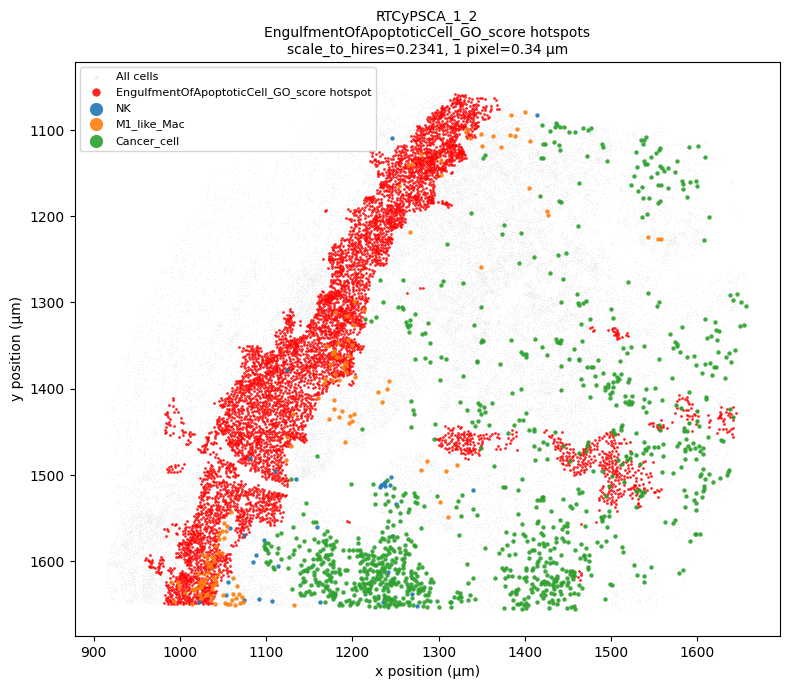

In [ ]:
# # Quick visual check of hotspots

# %%
# Change these as needed
# 'RTCyPSCA_1_2', 'RTCyPSCA_2_3'
plot_tissue = tissues_to_run[0]
plot_score = score_cols[1]

print(f"Plotting: {plot_tissue} | {plot_score}")

quick_hotspot_plot(
    adata=adata,
    sdata=sdata,
    tissue_name=plot_tissue,
    score_col=plot_score,
    overlay_cell_types=("NK", "M1_like_Mac", "Cancer_cell")
)

In [57]:
# %% [markdown]
# # Distance from pathway hotspots to target cell types

# %%
distance_records = []

for tissue_name in tissues_to_run:
    tissue_mask, coords_um, scale_to_hires = get_tissue_coords_um(adata, sdata, tissue_name)
    obs = adata.obs.loc[tissue_mask].copy()
    n_cells = len(obs)

    if n_cells < min_cells:
        continue

    treatment = (
        obs[condition_col].astype(str).iloc[0]
        if condition_col in obs.columns
        else "NA"
    )

    print(f"\nDistance analysis: {tissue_name} | n={n_cells:,}")

    for score_col in score_cols:
        hot_col = f"{score_col}_hotspot"

        if hot_col not in obs.columns:
            continue

        hotspot_mask = obs[hot_col].astype(bool).values
        n_hotspot = int(hotspot_mask.sum())

        if n_hotspot == 0:
            continue

        hotspot_coords = coords_um[hotspot_mask]

        for ct in target_cell_types:
            target_mask = obs[cell_type_col].astype(str).eq(ct).values
            n_target = int(target_mask.sum())

            record = {
                "tissue": tissue_name,
                "treatment": treatment,
                "score_col": score_col,
                "target_cell_type": ct,
                "n_cells": int(n_cells),
                "n_hotspot_cells": int(n_hotspot),
                "n_target_cells": int(n_target),
                "microns_per_pixel": float(MICRONS_PER_PIXEL),
                "scale_to_hires": float(scale_to_hires),
            }

            if n_target == 0:
                record.update({
                    "min_dist_um": np.nan,
                    "median_dist_um": np.nan,
                    "mean_dist_um": np.nan,
                })

                for threshold_um in distance_thresholds_um:
                    record[f"pct_hotspot_cells_within_{threshold_um}um"] = np.nan

                distance_records.append(record)
                continue

            target_coords = coords_um[target_mask]

            nn = NearestNeighbors(n_neighbors=1)
            nn.fit(target_coords)

            dists_um, _ = nn.kneighbors(hotspot_coords)
            dists_um = dists_um.ravel()

            record.update({
                "min_dist_um": float(np.min(dists_um)),
                "median_dist_um": float(np.median(dists_um)),
                "mean_dist_um": float(np.mean(dists_um)),
            })

            for threshold_um in distance_thresholds_um:
                record[f"pct_hotspot_cells_within_{threshold_um}um"] = float(
                    (dists_um <= threshold_um).mean() * 100
                )

            distance_records.append(record)

cell_distance_df = pd.DataFrame(distance_records)

display(
    cell_distance_df
    .sort_values(["score_col", "tissue", "median_dist_um"])
    .reset_index(drop=True)
)


Distance analysis: RTCyPSCA_1_2 | n=28,637

Distance analysis: RTCyPSCA_2_3 | n=112,486


,tissue,treatment,score_col,target_cell_type,n_cells,n_hotspot_cells,n_target_cells,microns_per_pixel,scale_to_hires,min_dist_um,median_dist_um,mean_dist_um,pct_hotspot_cells_within_25um,pct_hotspot_cells_within_50um,pct_hotspot_cells_within_100um
0,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,N1_like_Neu,28637,12001,3816,0.34,0.234119,0.0,3.274444,4.317280,99.625031,100.000000,100.000000
1,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,N2_like_Neu,28637,12001,1267,0.34,0.234119,0.0,11.631643,14.832477,84.376302,98.183485,100.000000
2,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,M2_like_Mac,28637,12001,466,0.34,0.234119,0.0,16.718794,21.817871,67.827681,91.492376,100.000000
3,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,M1_like_Mac,28637,12001,146,0.34,0.234119,0.0,22.789698,31.450619,53.953837,81.609866,96.116990
4,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,Cancer_cell,28637,12001,1027,0.34,0.234119,0.0,28.341269,35.245397,43.879677,75.452046,97.966836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,RTCyPSCA_2_3,RTCyPSCA_Tu2,VacuolarAcidification_GO_score,M2_like_Mac,112486,11758,1899,0.34,0.230574,0.0,9.986442,14.519153,79.290696,99.030447,100.000000
140,RTCyPSCA_2_3,RTCyPSCA_Tu2,VacuolarAcidification_GO_score,Cancer_cell,112486,11758,12346,0.34,0.230574,0.0,14.634491,23.907843,65.028066,83.815275,99.761864
141,RTCyPSCA_2_3,RTCyPSCA_Tu2,VacuolarAcidification_GO_score,CD8_T,112486,11758,872,0.34,0.230574,0.0,22.144476,25.268307,56.106481,91.750298,100.000000
142,RTCyPSCA_2_3,RTCyPSCA_Tu2,VacuolarAcidification_GO_score,cDC,112486,11758,258,0.34,0.230574,0.0,27.278983,30.250550,45.407382,85.252594,100.000000


In [58]:
# %% [markdown]
# # Cell-type composition inside pathway hotspots

# %%
composition_records = []

for tissue_name in tissues_to_run:
    tissue_mask = adata.obs[tissue_col].astype(str).eq(str(tissue_name)).values
    obs = adata.obs.loc[tissue_mask].copy()

    if len(obs) < min_cells:
        continue

    treatment = (
        obs[condition_col].astype(str).iloc[0]
        if condition_col in obs.columns
        else "NA"
    )

    for score_col in score_cols:
        hot_col = f"{score_col}_hotspot"

        if hot_col not in obs.columns:
            continue

        hot_obs = obs[obs[hot_col].astype(bool)].copy()

        if hot_obs.empty:
            continue

        counts = hot_obs[cell_type_col].astype(str).value_counts()
        props = counts / counts.sum()

        for ct in counts.index:
            composition_records.append({
                "tissue": tissue_name,
                "treatment": treatment,
                "score_col": score_col,
                "cell_type": ct,
                "n_cells_in_hotspot": int(counts.loc[ct]),
                "pct_cells_in_hotspot": float(props.loc[ct] * 100),
                "total_hotspot_cells": int(counts.sum()),
            })

hotspot_composition_df = pd.DataFrame(composition_records)

display(
    hotspot_composition_df
    .sort_values(
        ["score_col", "tissue", "pct_cells_in_hotspot"],
        ascending=[True, True, False]
    )
    .reset_index(drop=True)
)

,tissue,treatment,score_col,cell_type,n_cells_in_hotspot,pct_cells_in_hotspot,total_hotspot_cells
0,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,Unknown,6468,53.895509,12001
1,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,N1_like_Neu,2079,17.323556,12001
2,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,Classical_Mono,1328,11.065745,12001
3,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,Erythrocyte,1247,10.390801,12001
4,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,N2_like_Neu,221,1.841513,12001
...,...,...,...,...,...,...,...
345,RTCyPSCA_2_3,RTCyPSCA_Tu2,VacuolarAcidification_GO_score,pDC,10,0.085048,11758
346,RTCyPSCA_2_3,RTCyPSCA_Tu2,VacuolarAcidification_GO_score,CD4_T,8,0.068039,11758
347,RTCyPSCA_2_3,RTCyPSCA_Tu2,VacuolarAcidification_GO_score,NKT,8,0.068039,11758
348,RTCyPSCA_2_3,RTCyPSCA_Tu2,VacuolarAcidification_GO_score,Fibroblast,8,0.068039,11758


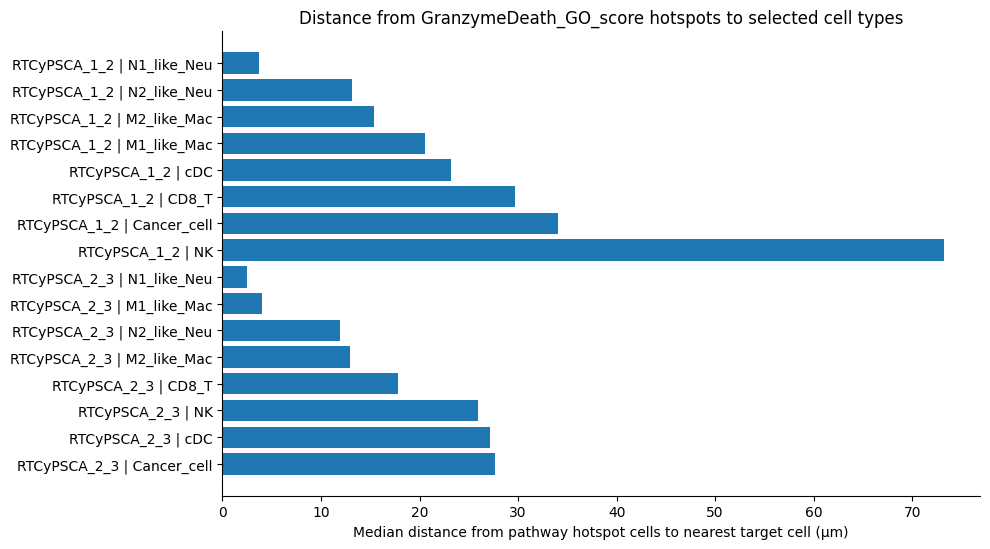

In [59]:
# %% [markdown]
# # Quick distance plot

# %%
plot_score = "GranzymeDeath_GO_score"

if plot_score not in cell_distance_df["score_col"].unique():
    plot_score = cell_distance_df["score_col"].iloc[0]

plot_cell_types = ["NK", "CD8_T", "M1_like_Mac", "M2_like_Mac", "cDC", "N1_like_Neu", "N2_like_Neu", "Cancer_cell"]

df_plot = cell_distance_df.query(
    "score_col == @plot_score and target_cell_type in @plot_cell_types"
).copy()

df_plot = df_plot.sort_values(["tissue", "median_dist_um"])

fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(df_plot))))

labels = df_plot["tissue"].astype(str) + " | " + df_plot["target_cell_type"].astype(str)

ax.barh(labels, df_plot["median_dist_um"])
ax.set_xlabel("Median distance from pathway hotspot cells to nearest target cell (µm)")
ax.set_title(f"Distance from {plot_score} hotspots to selected cell types")
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
display(fig)
plt.close(fig)

In [60]:
# %% [markdown]
# # Optional: create local cell-type density scores

# %%
# This makes continuous local-density scores for cell types.
# Example: NK_density_k50 = fraction of local kNN neighborhood that is NK.
# These can be used as cell-type hotspot inputs later.

density_k = 50

for ct in target_cell_types:
    density_col = f"{ct}_density_k{density_k}"
    adata.obs[density_col] = np.nan

for tissue_name in tissues_to_run:
    tissue_mask, coords_um, scale_to_hires = get_tissue_coords_um(adata, sdata, tissue_name)
    obs = adata.obs.loc[tissue_mask].copy()
    obs_names = adata.obs_names[tissue_mask]

    if len(obs) < min_cells:
        continue

    n_neighbors = min(density_k + 1, len(obs))

    nn = NearestNeighbors(n_neighbors=n_neighbors)
    nn.fit(coords_um)
    _, idx = nn.kneighbors(coords_um)

    cell_types = obs[cell_type_col].astype(str).values

    print(f"\nLocal density scores: {tissue_name}")

    for ct in target_cell_types:
        density_col = f"{ct}_density_k{density_k}"
        is_ct = (cell_types == ct).astype(float)

        # Mean over local neighborhood, including self.
        local_density = is_ct[idx].mean(axis=1)

        adata.obs.loc[obs_names, density_col] = local_density

        print(f"  {density_col}: mean={local_density.mean():.4f}, max={local_density.max():.4f}")

cell_density_score_cols = [f"{ct}_density_k{density_k}" for ct in target_cell_types]

print("\nCell-type density columns added:")
print(cell_density_score_cols)


Local density scores: RTCyPSCA_1_2
  NK_density_k50: mean=0.0012, max=0.1373
  CD8_T_density_k50: mean=0.0046, max=0.1569
  M1_like_Mac_density_k50: mean=0.0051, max=0.2745
  M2_like_Mac_density_k50: mean=0.0161, max=0.3725
  cDC_density_k50: mean=0.0044, max=0.3137
  N1_like_Neu_density_k50: mean=0.1316, max=0.6471
  N2_like_Neu_density_k50: mean=0.0434, max=0.8627
  Cancer_cell_density_k50: mean=0.0357, max=0.8039

Local density scores: RTCyPSCA_2_3
  NK_density_k50: mean=0.0027, max=0.1765
  CD8_T_density_k50: mean=0.0078, max=0.4314
  M1_like_Mac_density_k50: mean=0.0420, max=0.8431
  M2_like_Mac_density_k50: mean=0.0167, max=0.5490
  cDC_density_k50: mean=0.0023, max=0.1176
  N1_like_Neu_density_k50: mean=0.1443, max=0.6667
  N2_like_Neu_density_k50: mean=0.0554, max=0.7647
  Cancer_cell_density_k50: mean=0.1088, max=0.8824

Cell-type density columns added:
['NK_density_k50', 'CD8_T_density_k50', 'M1_like_Mac_density_k50', 'M2_like_Mac_density_k50', 'cDC_density_k50', 'N1_like_Ne

In [61]:
# %% [markdown]
# # Optional: Getis-Ord Gi* hotspots for cell-type density scores

# %%
celltype_hotspot_summary = []

for density_col in cell_density_score_cols:
    adata.obs[f"{density_col}_GiZ"] = np.nan
    adata.obs[f"{density_col}_q_hot"] = np.nan
    adata.obs[f"{density_col}_q_cold"] = np.nan
    adata.obs[f"{density_col}_hotspot"] = False
    adata.obs[f"{density_col}_coldspot"] = False

for tissue_name in tissues_to_run:
    tissue_mask, coords_um, scale_to_hires = get_tissue_coords_um(adata, sdata, tissue_name)
    obs = adata.obs.loc[tissue_mask].copy()
    obs_names = adata.obs_names[tissue_mask]

    if len(obs) < min_cells:
        continue

    treatment = (
        obs[condition_col].astype(str).iloc[0]
        if condition_col in obs.columns
        else "NA"
    )

    print(f"\nCell-type density hotspots: {tissue_name}")

    for density_col in cell_density_score_cols:
        values = obs[density_col].astype(float).values
        good = np.isfinite(values)

        if good.sum() < min_cells or np.nanmax(values) == 0:
            print(f"  Skipping {density_col}: no/low signal")
            continue

        z, q_hot, q_cold = calc_getis_ord_gi_star(
            coords_um=coords_um[good],
            values=values[good],
            k=k_gi
        )

        hotspot = (z > 0) & (q_hot < alpha)
        coldspot = (z < 0) & (q_cold < alpha)

        sub_obs_names = obs_names[good]

        adata.obs.loc[sub_obs_names, f"{density_col}_GiZ"] = z
        adata.obs.loc[sub_obs_names, f"{density_col}_q_hot"] = q_hot
        adata.obs.loc[sub_obs_names, f"{density_col}_q_cold"] = q_cold
        adata.obs.loc[sub_obs_names, f"{density_col}_hotspot"] = hotspot
        adata.obs.loc[sub_obs_names, f"{density_col}_coldspot"] = coldspot

        celltype_hotspot_summary.append({
            "tissue": tissue_name,
            "treatment": treatment,
            "density_col": density_col,
            "n_cells": int(len(obs)),
            "n_hotspot_cells": int(hotspot.sum()),
            "pct_hotspot_cells": float(hotspot.mean() * 100),
            "n_coldspot_cells": int(coldspot.sum()),
            "pct_coldspot_cells": float(coldspot.mean() * 100),
        })

        print(
            f"  {density_col}: "
            f"hot={hotspot.sum():,} ({hotspot.mean()*100:.1f}%), "
            f"cold={coldspot.sum():,} ({coldspot.mean()*100:.1f}%)"
        )

celltype_hotspot_summary_df = pd.DataFrame(celltype_hotspot_summary)

display(
    celltype_hotspot_summary_df
    .sort_values(["density_col", "tissue"])
    .reset_index(drop=True)
)

/tmp/ipykernel_2459448/1921980395.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[f"{density_col}_q_hot"] = np.nan
/tmp/ipykernel_2459448/1921980395.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[f"{density_col}_q_cold"] = np.nan
/tmp/ipykernel_2459448/1921980395.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-frag


Cell-type density hotspots: RTCyPSCA_1_2
  NK_density_k50: hot=2,219 (7.7%), cold=0 (0.0%)
  CD8_T_density_k50: hot=3,801 (13.3%), cold=21,394 (74.7%)
  M1_like_Mac_density_k50: hot=3,198 (11.2%), cold=21,911 (76.5%)
  M2_like_Mac_density_k50: hot=5,383 (18.8%), cold=17,073 (59.6%)
  cDC_density_k50: hot=4,072 (14.2%), cold=20,206 (70.6%)
  N1_like_Neu_density_k50: hot=10,667 (37.2%), cold=12,978 (45.3%)
  N2_like_Neu_density_k50: hot=4,883 (17.1%), cold=15,494 (54.1%)
  Cancer_cell_density_k50: hot=3,965 (13.8%), cold=18,725 (65.4%)

Cell-type density hotspots: RTCyPSCA_2_3
  NK_density_k50: hot=15,432 (13.7%), cold=85,402 (75.9%)
  CD8_T_density_k50: hot=16,110 (14.3%), cold=73,656 (65.5%)
  M1_like_Mac_density_k50: hot=14,332 (12.7%), cold=85,464 (76.0%)
  M2_like_Mac_density_k50: hot=18,701 (16.6%), cold=69,083 (61.4%)
  cDC_density_k50: hot=18,797 (16.7%), cold=80,515 (71.6%)
  N1_like_Neu_density_k50: hot=38,881 (34.6%), cold=50,344 (44.8%)
  N2_like_Neu_density_k50: hot=26,237 

,tissue,treatment,density_col,n_cells,n_hotspot_cells,pct_hotspot_cells,n_coldspot_cells,pct_coldspot_cells
0,RTCyPSCA_1_2,RTCyPSCA_Tu1,CD8_T_density_k50,28637,3801,13.273038,21394,74.707546
1,RTCyPSCA_2_3,RTCyPSCA_Tu2,CD8_T_density_k50,112486,16110,14.321782,73656,65.480149
2,RTCyPSCA_1_2,RTCyPSCA_Tu1,Cancer_cell_density_k50,28637,3965,13.845724,18725,65.387436
3,RTCyPSCA_2_3,RTCyPSCA_Tu2,Cancer_cell_density_k50,112486,34213,30.415341,60375,53.673346
4,RTCyPSCA_1_2,RTCyPSCA_Tu1,M1_like_Mac_density_k50,28637,3198,11.167371,21911,76.512903
5,RTCyPSCA_2_3,RTCyPSCA_Tu2,M1_like_Mac_density_k50,112486,14332,12.741141,85464,75.977455
6,RTCyPSCA_1_2,RTCyPSCA_Tu1,M2_like_Mac_density_k50,28637,5383,18.797360,17073,59.618675
7,RTCyPSCA_2_3,RTCyPSCA_Tu2,M2_like_Mac_density_k50,112486,18701,16.625180,69083,61.414754
8,RTCyPSCA_1_2,RTCyPSCA_Tu1,N1_like_Neu_density_k50,28637,10667,37.249014,12978,45.318993
9,RTCyPSCA_2_3,RTCyPSCA_Tu2,N1_like_Neu_density_k50,112486,38881,34.565190,50344,44.755792


In [62]:
# %% [markdown]
# # Optional: distance from pathway hotspots to cell-type density hotspots

# %%
hotspot_to_hotspot_records = []

for tissue_name in tissues_to_run:
    tissue_mask, coords_um, scale_to_hires = get_tissue_coords_um(adata, sdata, tissue_name)
    obs = adata.obs.loc[tissue_mask].copy()

    if len(obs) < min_cells:
        continue

    treatment = (
        obs[condition_col].astype(str).iloc[0]
        if condition_col in obs.columns
        else "NA"
    )

    print(f"\nHotspot-to-hotspot distance: {tissue_name}")

    for score_col in score_cols:
        pathway_hot_col = f"{score_col}_hotspot"

        if pathway_hot_col not in obs.columns:
            continue

        pathway_hot_mask = obs[pathway_hot_col].astype(bool).values

        if pathway_hot_mask.sum() == 0:
            continue

        pathway_hot_coords = coords_um[pathway_hot_mask]

        for density_col in cell_density_score_cols:
            celltype_hot_col = f"{density_col}_hotspot"

            if celltype_hot_col not in obs.columns:
                continue

            celltype_hot_mask = obs[celltype_hot_col].astype(bool).values

            record = {
                "tissue": tissue_name,
                "treatment": treatment,
                "pathway_score_col": score_col,
                "celltype_density_col": density_col,
                "n_pathway_hotspot_cells": int(pathway_hot_mask.sum()),
                "n_celltype_hotspot_cells": int(celltype_hot_mask.sum()),
                "microns_per_pixel": float(MICRONS_PER_PIXEL),
                "scale_to_hires": float(scale_to_hires),
            }

            if celltype_hot_mask.sum() == 0:
                record.update({
                    "min_dist_um": np.nan,
                    "median_dist_um": np.nan,
                    "mean_dist_um": np.nan,
                })
                hotspot_to_hotspot_records.append(record)
                continue

            celltype_hot_coords = coords_um[celltype_hot_mask]

            nn = NearestNeighbors(n_neighbors=1)
            nn.fit(celltype_hot_coords)

            dists_um, _ = nn.kneighbors(pathway_hot_coords)
            dists_um = dists_um.ravel()

            record.update({
                "min_dist_um": float(np.min(dists_um)),
                "median_dist_um": float(np.median(dists_um)),
                "mean_dist_um": float(np.mean(dists_um)),
            })

            for threshold_um in distance_thresholds_um:
                record[f"pct_pathway_hotspot_cells_within_{threshold_um}um"] = float(
                    (dists_um <= threshold_um).mean() * 100
                )

            hotspot_to_hotspot_records.append(record)

hotspot_to_hotspot_distance_df = pd.DataFrame(hotspot_to_hotspot_records)

display(
    hotspot_to_hotspot_distance_df
    .sort_values(["pathway_score_col", "tissue", "median_dist_um"])
    .reset_index(drop=True)
)


Hotspot-to-hotspot distance: RTCyPSCA_1_2

Hotspot-to-hotspot distance: RTCyPSCA_2_3


,tissue,treatment,pathway_score_col,celltype_density_col,n_pathway_hotspot_cells,n_celltype_hotspot_cells,microns_per_pixel,scale_to_hires,min_dist_um,median_dist_um,mean_dist_um,pct_pathway_hotspot_cells_within_25um,pct_pathway_hotspot_cells_within_50um,pct_pathway_hotspot_cells_within_100um
0,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,N1_like_Neu_density_k50,12001,10667,0.34,0.234119,0.0,0.000000,13.876392,77.001917,90.984085,99.891676
1,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,M1_like_Mac_density_k50,12001,3198,0.34,0.234119,0.0,14.823241,23.486105,64.436297,86.759437,97.416882
2,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,M2_like_Mac_density_k50,12001,5383,0.34,0.234119,0.0,22.633157,27.802224,53.178902,81.551537,98.400133
3,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,cDC_density_k50,12001,4072,0.34,0.234119,0.0,22.875689,31.950027,52.903925,74.318807,97.200233
4,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,CD8_T_density_k50,12001,3801,0.34,0.234119,0.0,28.768131,35.997446,45.571202,71.369053,95.608699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,RTCyPSCA_2_3,RTCyPSCA_Tu2,VacuolarAcidification_GO_score,CD8_T_density_k50,11758,16110,0.34,0.230574,0.0,18.952933,22.167538,61.702671,93.782956,99.498214
140,RTCyPSCA_2_3,RTCyPSCA_Tu2,VacuolarAcidification_GO_score,NK_density_k50,11758,15432,0.34,0.230574,0.0,24.217455,27.912477,51.258717,84.716789,99.030447
141,RTCyPSCA_2_3,RTCyPSCA_Tu2,VacuolarAcidification_GO_score,M1_like_Mac_density_k50,11758,14332,0.34,0.230574,0.0,29.316424,133.497142,48.724273,54.482055,57.969042
142,RTCyPSCA_2_3,RTCyPSCA_Tu2,VacuolarAcidification_GO_score,N2_like_Neu_density_k50,11758,26237,0.34,0.230574,0.0,37.337766,52.390996,43.102568,58.368770,80.762034


# Saving

In [ ]:
# %% [markdown]
# # Save results

# %%
out_dir = Gemini_proj_dir / "results/getis_ord_gistar_quick"
out_dir.mkdir(parents=True, exist_ok=True)

hotspot_summary_df.to_csv(out_dir / "pathway_hotspot_summary.csv", index=False)
cell_distance_df.to_csv(out_dir / "pathway_hotspot_to_celltype_distances_um.csv", index=False)
hotspot_composition_df.to_csv(out_dir / "pathway_hotspot_celltype_composition.csv", index=False)

if "celltype_hotspot_summary_df" in globals():
    celltype_hotspot_summary_df.to_csv(out_dir / "celltype_density_hotspot_summary.csv", index=False)

if "hotspot_to_hotspot_distance_df" in globals():
    hotspot_to_hotspot_distance_df.to_csv(out_dir / "pathway_hotspot_to_celltype_density_hotspot_distances_um.csv", index=False)

hotspot_cols = [
    c for c in adata.obs.columns
    if c.endswith("_GiZ")
    or c.endswith("_q_hot")
    or c.endswith("_q_cold")
    or c.endswith("_hotspot")
    or c.endswith("_coldspot")
    or c.endswith("_hotspot_component")
    or "_density_k" in c
]

metadata_cols = [
    c for c in [tissue_col, condition_col, cell_type_col]
    if c in adata.obs.columns
]

adata.obs[metadata_cols + hotspot_cols].to_csv(
    out_dir / "adata_obs_gistar_hotspot_labels.csv"
)

print(f"Saved results to: {out_dir}")
print(f"Saved {len(hotspot_cols)} hotspot/density columns.")

# Answers

In [64]:
cell_distance_df.sort_values(["score_col", "tissue", "median_dist_um"])

,tissue,treatment,score_col,target_cell_type,n_cells,n_hotspot_cells,n_target_cells,microns_per_pixel,scale_to_hires,min_dist_um,median_dist_um,mean_dist_um,pct_hotspot_cells_within_25um,pct_hotspot_cells_within_50um,pct_hotspot_cells_within_100um
45,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,N1_like_Neu,28637,12001,3816,0.34,0.234119,0.0,3.274444,4.317280,99.625031,100.000000,100.000000
46,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,N2_like_Neu,28637,12001,1267,0.34,0.234119,0.0,11.631643,14.832477,84.376302,98.183485,100.000000
43,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,M2_like_Mac,28637,12001,466,0.34,0.234119,0.0,16.718794,21.817871,67.827681,91.492376,100.000000
42,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,M1_like_Mac,28637,12001,146,0.34,0.234119,0.0,22.789698,31.450619,53.953837,81.609866,96.116990
47,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,Cancer_cell,28637,12001,1027,0.34,0.234119,0.0,28.341269,35.245397,43.879677,75.452046,97.966836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,RTCyPSCA_2_3,RTCyPSCA_Tu2,VacuolarAcidification_GO_score,M2_like_Mac,112486,11758,1899,0.34,0.230574,0.0,9.986442,14.519153,79.290696,99.030447,100.000000
103,RTCyPSCA_2_3,RTCyPSCA_Tu2,VacuolarAcidification_GO_score,Cancer_cell,112486,11758,12346,0.34,0.230574,0.0,14.634491,23.907843,65.028066,83.815275,99.761864
97,RTCyPSCA_2_3,RTCyPSCA_Tu2,VacuolarAcidification_GO_score,CD8_T,112486,11758,872,0.34,0.230574,0.0,22.144476,25.268307,56.106481,91.750298,100.000000
100,RTCyPSCA_2_3,RTCyPSCA_Tu2,VacuolarAcidification_GO_score,cDC,112486,11758,258,0.34,0.230574,0.0,27.278983,30.250550,45.407382,85.252594,100.000000


In [65]:
hotspot_to_hotspot_distance_df.sort_values(["pathway_score_col", "tissue", "median_dist_um"])

,tissue,treatment,pathway_score_col,celltype_density_col,n_pathway_hotspot_cells,n_celltype_hotspot_cells,microns_per_pixel,scale_to_hires,min_dist_um,median_dist_um,mean_dist_um,pct_pathway_hotspot_cells_within_25um,pct_pathway_hotspot_cells_within_50um,pct_pathway_hotspot_cells_within_100um
45,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,N1_like_Neu_density_k50,12001,10667,0.34,0.234119,0.0,0.000000,13.876392,77.001917,90.984085,99.891676
42,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,M1_like_Mac_density_k50,12001,3198,0.34,0.234119,0.0,14.823241,23.486105,64.436297,86.759437,97.416882
43,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,M2_like_Mac_density_k50,12001,5383,0.34,0.234119,0.0,22.633157,27.802224,53.178902,81.551537,98.400133
44,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,cDC_density_k50,12001,4072,0.34,0.234119,0.0,22.875689,31.950027,52.903925,74.318807,97.200233
41,RTCyPSCA_1_2,RTCyPSCA_Tu1,AntigenPresentation_GO_score,CD8_T_density_k50,12001,3801,0.34,0.234119,0.0,28.768131,35.997446,45.571202,71.369053,95.608699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,RTCyPSCA_2_3,RTCyPSCA_Tu2,VacuolarAcidification_GO_score,CD8_T_density_k50,11758,16110,0.34,0.230574,0.0,18.952933,22.167538,61.702671,93.782956,99.498214
96,RTCyPSCA_2_3,RTCyPSCA_Tu2,VacuolarAcidification_GO_score,NK_density_k50,11758,15432,0.34,0.230574,0.0,24.217455,27.912477,51.258717,84.716789,99.030447
98,RTCyPSCA_2_3,RTCyPSCA_Tu2,VacuolarAcidification_GO_score,M1_like_Mac_density_k50,11758,14332,0.34,0.230574,0.0,29.316424,133.497142,48.724273,54.482055,57.969042
102,RTCyPSCA_2_3,RTCyPSCA_Tu2,VacuolarAcidification_GO_score,N2_like_Neu_density_k50,11758,26237,0.34,0.230574,0.0,37.337766,52.390996,43.102568,58.368770,80.762034
